# Chapter 21. 작은 BERT 분류 — 영어 Yelp 이진 (일반 도메인 사전학습 → 다른 도메인 fine-tune)

**목표**: Phase 3 의 세 번째 챕터. Ch 20 에서 *작은 BERT 를 일반 도메인 (Wikitext-103) 으로 직접 MLM 사전학습* 했다면, 이번엔 그 위에 **분류 헤드를 얹어 *완전히 다른 도메인 (Yelp 리뷰(식당·업체))* 이진 분류로 fine-tune** 합니다. Ch 10 (DistilBERT, 약 66M params, 대규모 Wikipedia + BookCorpus 사전학습) 과 같은 Yelp 이진 분류 셋업에 *우리가 만든 작은 BERT* (약 10M params, Wikitext-103 2K paragraphs × 3 epoch MLM) 를 붙여 두 결과를 나란히 비교 — 둘 다 *일반 도메인 → Yelp transfer* 라 비교가 *fair*, *사전학습 규모* 차이만 측정됨.

본 챕터의 강점: *위키 사전학습 → Yelp 분류 transfer* 가 **진짜 transfer**. *task corpus 로 사전학습 → 같은 task fine-tune* 의 domain-adaptive pretraining 함정을 피해 원본 BERT 의 *일반 표상 학습 → downstream 전이* 메시지를 그대로 재현합니다. **두 데이터셋이 노트북 안에 공존** — MLM 용 Wikitext-103 (2K paragraphs × 3 epoch) + 분류용 Yelp 이진 (5K/1K).

self-contained 노트북: Ch 20 의 MLM 학습을 압축 (2K × 3 epoch) 재현 → 같은 본체로 분류 fine-tune → Ch 10 결과와 비교. **한국어 Ch 23 self-contained 와 동일한 hyperparams** 로 영어/한국어 챕터 짝의 일관성 유지. 본문은 *사전학습 → 분류 fine-tune* 메인 흐름에 집중. *사전학습 없이 같은 GPU compute 로 분류 fine-tune* 만 했을 때의 fair-compute 비교는 부록 노트북 [`appendix_compute_budget.ipynb`](./appendix_compute_budget.ipynb) 에서 분리해 다룹니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 25-28분 (Wikitext-103 다운로드·필터링 약 2분 + MLM 3 epoch 약 8-10분 + 분류 fine-tune 2 epoch 약 8-10분 + 평가 약 2분)

---

## 학습 흐름

1. 🚀 **분류 데이터**: `fancyzhx/yelp_polarity` 이진 분류 (Ch 10 과 같은 5K/1K split, seed 42)
2. 🔤 **토크나이저**: `bert-base-uncased` (Ch 20 과 동일)
3. 📥 **MLM 사전학습 데이터**: `Salesforce/wikitext` config `wikitext-103-raw-v1` paragraphs 5K (일반 도메인 — *분류용 Yelp 와 별도*)
4. 🏗️ **MLM 사전학습 재현 (Ch 20 압축본)**: 같은 작은 BertConfig 로 2K paragraphs × 3 epoch (한국어 Ch 23 와 동일)
5. 🔀 **헤드 교체**: `BertForMaskedLM` → `BertForSequenceClassification(num_labels=2)`. 본체는 그대로, MLM head 떼고 분류 head 부착
6. 🚀 **분류 fine-tune**: Trainer fp16, 2 epoch
7. 🔬 **평가**: accuracy / precision / recall / F1 / AUC (Ch 10 과 같은 5종)
8. 🆚 **Ch 10 vs Ch 21 비교 표**: 정확도, 모델 크기, 사전학습 토큰량

📒 **부록**: [`appendix_compute_budget.ipynb`](./appendix_compute_budget.ipynb) — 같은 GPU compute budget 으로 *사전학습 없이* 분류 fine-tune 만 했을 때의 fair-compute 비교

---

> 📒 **사전 학습 자료**: Ch 20 (작은 BERT scratch MLM, Wikitext-103), Ch 10 (DistilBERT 사전학습 + Yelp 이진 분류). Ch 21 은 두 챕터를 *합쳐서* — Ch 20 의 일반 도메인 사전학습 흐름 그대로 + Ch 10 의 fine-tune 평가 그대로. Ch 22-23 (한국어 위키 → NSMC) 의 *대칭 패턴*.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 10 | DistilBERT 파인튜닝 (약 66M) | `bert-base-uncased` WordPiece | Yelp 이진 (4-5 → 1, 1-2 → 0) | `Linear(H, 1)` | sigmoid | `BCEWithLogitsLoss` |
| 18 | klue/bert-base + 보조 | WordPiece (한국어, 사전학습) | KLUE-YNAT 합성 + 보조 라벨 | 메인(7) + 보조 | sigmoid + 태스크별 | `BCEWithLogitsLoss + λ·L_aux` |
| 19 | — (토크나이저 학습 전용) | WordPiece + WordLevel (둘 다 직접 학습) | Yelp text + NSMC text | — | — | — |
| 20 | 작은 BERT (직접, scratch) | `bert-base-uncased` 토크나이저 (가져옴) | Wikitext-103 paragraphs (일반 도메인) | MLM head | softmax (MLM) | `CrossEntropyLoss` (masked token) |
| **21 ← 여기** | **Ch 20 사전학습 BERT + 분류 헤드 (약 10M)** | (Ch 20과 동일) | **Yelp 이진화 (다른 도메인 transfer)** | **`Linear(H, 2)`** | **softmax** | **`CrossEntropyLoss`** |
| 22 (다음) | 작은 BERT (직접, scratch) — 한국어 | `klue/bert-base` 토크나이저 (가져옴) | 한국어 Wikipedia paragraphs (일반 도메인) | MLM head | softmax (MLM) | `CrossEntropyLoss` (masked token) |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

**Phase 3 안에서의 위치** — Ch 19 (토크나이저 학습) → Ch 20 (모델 사전학습) → **Ch 21 (분류 fine-tune)** → Ch 22 (한국어 사전학습) → Ch 23 (한국어 분류). Ch 21 이 Phase 3 의 *영어 절반 마무리* — Ch 10 비교가 클라이맥스.

## 🔄 변경점 (Diff from Ch 20)

| 축 | Ch 20 (작은 BERT scratch MLM, 위키) | Ch 21 (작은 BERT 분류 fine-tune, Yelp) |
|---|---|---|
| **이 챕터의 task** | MLM 사전학습 (masked token 예측) | **이진 분류 (긍정/부정)** ← *task 축 변화* |
| 모델 클래스 | `BertForMaskedLM` | **`BertForSequenceClassification(num_labels=2)`** |
| 본체 (embedding + encoder) | random init → MLM 학습 | **Ch 20 사전학습 본체 그대로 이어받음** |
| 출력 헤드 | MLM head (vocab 30,522 차원) | **분류 head (`Linear(256, 2)`)** ← 새 random init |
| 토크나이저 | `bert-base-uncased` (vocab 30,522) | (그대로) |
| **데이터** | **Wikitext-103 paragraphs (일반 도메인, 라벨 없음)** | **Yelp 이진 (다른 도메인, 라벨 사용)** ← *사전학습과 fine-tune 도메인이 다름* |
| Loss | `CrossEntropyLoss` (vocab 30,522 logits) | **`CrossEntropyLoss` (2 logits)** ← K 만 큰 변화 |
| 학습률 | 5e-4 (scratch 사전학습) | **2e-5** (fine-tune, 표준) |

> **변경점 한 가지 원칙** — Phase 3 안에서 *task 축* 이 변합니다 (MLM → 분류). 데이터 *도메인* 도 같이 변합니다 (위키 → Yelp) — 이게 *진짜 transfer 의 본질*. 모델 본체·토크나이저는 그대로, 헤드와 라벨 형식·데이터 도메인이 바뀝니다. 이게 *사전학습-fine-tune 패러다임* 의 핵심: 본체는 한 번 학습한 *일반 표상* 을 재사용, downstream task 도메인마다 *작은 헤드 + 작은 학습률* 로 적응.

### 두 데이터셋이 노트북 안에 공존

본 챕터의 특수성 — 한 노트북에 두 데이터셋이 함께 들어갑니다.

| 단계 | 데이터셋 | 용도 |
|---|---|---|
| 3 §MLM 사전학습 | `Salesforce/wikitext`, `wikitext-103-raw-v1` 2K paragraphs × 3 epoch | self-supervised MLM (라벨 없음, 일반 위키 본문) |
| 4-5 §분류 fine-tune | `fancyzhx/yelp_polarity` 5K/1K | supervised 이진 분류 (긍정/부정 라벨) |

같은 토크나이저 (`bert-base-uncased`) 가 두 데이터셋의 모든 텍스트를 처리. 본체가 *위키 일반 어휘* 로 사전학습된 표상이 *Yelp 리뷰(식당·업체) 도메인 토큰* 에 얼마나 잘 전이되는가가 본 챕터의 측정 대상.

### Ch 10 (DistilBERT) 과의 비교가 본 챕터의 메인 메시지 — 이제 *fair*

| 차원 | Ch 10 (DistilBERT) | Ch 21 (이 챕터) | 비고 |
|---|---|---|---|
| 본체 파라미터 | 약 66M | **약 10M** | Ch 21 은 1/6 작음 |
| 사전학습 코퍼스 | Wikipedia + BookCorpus (약 33억 토큰, 일반 도메인) | **Wikitext-103 paragraphs 5K (약 70만-100만 토큰, 일반 도메인)** | 약 3000-5000배 격차, **둘 다 일반 위키** |
| 사전학습 시간 | TPU 수일 (대규모 인프라) | **T4 약 10분** | |
| Fine-tune 도메인 | Yelp 이진 (사전학습과 다른 도메인) | Yelp 이진 (사전학습과 다른 도메인) | **둘 다 일반 → Yelp transfer 라 fair** |
| 분류 fine-tune 셋업 | Ch 10 = 이번 챕터 동일 (같은 데이터, 같은 hyperparams) | | 변하는 건 *본체 출발점* 뿐 |
| 실측 accuracy | 약 0.90 | **약 0.65** | 실행본 기준 (Ch 10=0.9030, Ch 21=0.6490) |

비교가 *공정* 한 이유 — Ch 10 도 본 챕터도 둘 다 *일반 도메인 위키 사전학습 → Yelp 분류 transfer* 의 같은 패턴. *사전학습 규모* (3000-5000배) 와 *모델 크기* (6배) 만 차이. 만약 Ch 21 이 Yelp text 로 사전학습했다면 비교가 unfair 했을 것 — domain-adaptive pretraining 우위 때문.

이 격차가 *사전학습 규모의 가치* 를 정량으로 보여줍니다. *작은 일반 도메인 사전학습도 random init 보다는 낫다* 는 것, 그리고 *같은 GPU compute 를 fine-tune 에 모두 쏟아도 사전학습 효과를 메우기 어렵다* 는 것은 부록 노트북 [`appendix_compute_budget.ipynb`](./appendix_compute_budget.ipynb) 에서 fair-compute 관점으로 다룹니다.

## 📐 Loss 함수의 변화 — MLM CE (vocab=30,522) → 분류 CE (K=2)

Ch 20 의 MLM 도 본질은 *vocab 위에서의 다중 분류* 였습니다. 다만 K = vocab_size = 30,522 라 어려운 task. 이번 챕터는 K = 2 의 *훨씬 쉬운* 분류 task.

### 수식

분류 task 의 CE 는 Ch 11 과 같습니다 (K=2):

$$L_{\text{cls}} = -\frac{1}{N}\sum_{i=1}^{N} \log \hat p_{i, y_i}$$

- $\hat p_{i, k} = \mathrm{softmax}(z_i)_k$ — K=2 차원 softmax
- $y_i \in \{0, 1\}$ — 정수 라벨

### 두 CE 비교 (random baseline)

| task | K | random baseline loss $\log K$ | 학습 어려움 |
|---|---|---|---|
| MLM (Ch 20) | 30,522 | **10.33** | 매우 어려움 — 가려진 토큰 자리에 *vocab 전체 후보* 중 정답을 |
| 분류 (Ch 21) | 2 | **0.693** | 상대적으로 쉬움 — 긍정/부정 둘 중 하나 |

학습 첫 step 의 loss 가 약 0.693 부근이면 모델이 *균등 추측* 단계. fine-tune 첫 step 에서 분류 헤드만 새로 init 됐으므로 *이 정도* 가 정상.

### 사전학습 효과가 *loss 곡선* 에 어떻게 드러나나

| 셋업 | 학습 첫 step loss | 학습 종료 loss (epoch 2) | 메모 |
|---|---|---|---|
| random init + 분류 (부록) | 약 0.693 | 약 0.5-0.6 | 본체도 분류 헤드도 random — 학습이 *느림* |
| Wikitext-103 MLM 사전학습 본체 + 분류 (메인) | 약 0.693 | **약 0.3-0.5** | 본체에 *일반 위키 어휘·문맥 구조* 가 들어 있어 헤드가 Yelp 분류로 비교적 빠르게 적응 |
| Ch 10 DistilBERT 사전학습 본체 + 분류 | 약 0.693 | **약 0.15-0.25** | 대규모 일반 도메인 사전학습이 만든 표상의 위력 |

random baseline 은 *세 셋업 모두 같음* — 사전학습이 *학습 속도* 와 *수렴점* 에 영향. 학습 첫 step loss 가 같다고 사전학습이 의미 없는 게 아닙니다. *위키 사전학습 본체* 가 Yelp 도메인에서 *완벽한 성능* 을 내지는 못해도, random 보다 일관되게 빠르고 낮게 수렴.

> **숫자로 감 잡기** (K=2, 정답 = 클래스 1):
> | logits $(z_0, z_1)$ | softmax → $\hat p_1$ | 손실 |
> |---|---|---|
> | (0, 0) | 0.5 | **0.693** ← random |
> | (-1, +1) | 0.881 | 0.127 |
> | (-2, +2) | 0.982 | 0.018 |
> | (+2, -2) | 0.018 | **4.018** ← 자신 있게 틀림 |

## 🔤 토크나이저 노트

Ch 20 과 *완전히 동일* — `AutoTokenizer.from_pretrained("bert-base-uncased")`, vocab 30,522 영어 WordPiece. 사전학습-fine-tune 패러다임의 핵심: **토크나이저는 사전학습부터 분류까지 전 구간에서 동일** 해야 함. 그래야 본체가 학습한 토큰 임베딩이 그대로 의미를 유지.

### 두 도메인의 어휘 — 위키 vs Yelp

본 챕터의 두 데이터셋이 *같은 토크나이저* 를 공유하지만 *어휘 분포* 는 꽤 다릅니다.

- **Wikitext-103 (MLM 사전학습)**: 일반 위키 어휘 — 지명·인명·과학·역사 용어 (`capital`, `theorem`, `dynasty`, `proton` ...) 가 풍부. 격식 있는 문장 구조.
- **Yelp polarity (분류 fine-tune)**: 영화 리뷰 어휘 — 감성 형용사·구어체 (`amazing`, `terrible`, `loved`, `awful` ...) 가 풍부. 비격식 구어체.

같은 `bert-base-uncased` vocab (Wiki + BookCorpus 학습) 이 두 도메인을 *모두* 합리적으로 커버 — *위키 본문* 의 격식 어휘는 본 챕터 사전학습이 직접 본 분포, *Yelp 감성 어휘* 는 fine-tune 단계에서 본체가 적응. *토크나이저는 운명공동체* 라 vocab 미스매치가 없습니다.

### 분류 task 에서 [CLS] 토큰의 의미

MLM 사전학습 (Ch 20) 에서는 `group_texts` 패턴으로 *특수 토큰 없이* 토큰 스트림을 잘랐습니다. 분류 fine-tune 에서는 *문장 단위* 입력이라 표준 BERT 포맷:

```
[CLS] the food was excellent and the service was great [SEP]
```

- `[CLS]` 의 최종 hidden state $h_{[CLS]} \in \mathbb{R}^{256}$ 가 *문장 표상*. 분류 헤드 `Linear(256, 2)` 가 이 위에 얹힘.
- MLM 학습 중에는 `[CLS]` 의 hidden 이 *암묵적* 으로만 학습됨 (옆 토큰들과 attention 공유). 분류 fine-tune 단계에서 *이 자리* 가 본격 활용.

### 헤드 교체 시 어떤 파라미터가 어떻게 이어지나

| 모델 부분 | Ch 20 학습 끝 → Ch 21 시작 | 운명 |
|---|---|---|
| 임베딩 (vocab 30,522 × hidden 256) | Wikitext-103 사전학습으로 *일반 위키 어휘 표상* 학습 | **그대로 이어받음** (Yelp 어휘도 같은 vocab 안에 있어 호환) |
| Encoder 4 layer (attention + FFN) | MLM 으로 *문맥 의존 표상* 학습 | **그대로 이어받음** |
| MLM head (`cls.predictions`) | vocab 위 분류 헤드 | **버려짐** |
| 분류 head (`classifier`, `Linear(256, 2)`) | (없었음) | **새로 random init** ← Yelp fine-tune 으로 학습 |

> Ch 10 의 DistilBERT 가 같은 흐름 (일반 도메인 MLM 사전학습 → Yelp 분류 fine-tune) 을 *큰 규모* 로 거친 결과. 우리도 같은 흐름을 *작은 규모* 로 직접 거칩니다 — 둘 다 *위키 → Yelp transfer* 라 비교가 fair.

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/48.9 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 164.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 164.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForMaskedLM,
    BertForSequenceClassification,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, roc_auc_score, confusion_matrix,
)

plt.rcParams["axes.unicode_minus"] = False

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — both MLM and classification will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


**baseline VRAM** (CUDA 환경에서만 의미 있는 출력 — Colab T4 기준):

In [3]:
!nvidia-smi

Mon Jun 22 12:16:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 📥 Yelp 이진 분류 데이터 로드 — Ch 10 과 같은 split

`fancyzhx/yelp_polarity` 는 *이미 이진화된* (긍정/부정) 5점 척도 yelp 리뷰 데이터셋. Ch 10 의 `Yelp/yelp_review_full` + 별점 이진화 와 *완전히 같은 형태* 의 결과가 나오도록 같은 seed·같은 sample 수를 적용. **5,000 train / 1,000 eval, seed 42**.

In [4]:
SEED = 42
N_TRAIN = 5000
N_EVAL = 1000

ds_raw = load_dataset("fancyzhx/yelp_polarity")
print(f"splits: {list(ds_raw.keys())}")
print(f"train size: {len(ds_raw['train']):,}")
print(f"test size:  {len(ds_raw['test']):,}")
print(f"label names: {ds_raw['train'].features['label'].names}")

# Ch 10 과 동일한 seed·크기로 sample
ds_train_full = ds_raw["train"].shuffle(seed=SEED).select(range(N_TRAIN))
ds_eval_full  = ds_raw["test"].shuffle(seed=SEED).select(range(N_EVAL))

# 클래스 분포
train_labels = np.array(ds_train_full["label"])
eval_labels  = np.array(ds_eval_full["label"])
print(f"\nsampled train: {len(ds_train_full):,}")
print(f"  positive rate: {train_labels.mean():.1%}  (label 1)")
print(f"sampled eval:  {len(ds_eval_full):,}")
print(f"  positive rate: {eval_labels.mean():.1%}  (label 1)")

print(f"\nfirst train sample:")
print(f"  label: {ds_train_full[0]['label']} ({ds_raw['train'].features['label'].names[ds_train_full[0]['label']]})")
print(f"  text:  {ds_train_full[0]['text'][:200]}...")

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

splits: ['train', 'test']
train size: 560,000
test size:  38,000
label names: ['1', '2']



sampled train: 5,000
  positive rate: 50.7%  (label 1)
sampled eval:  1,000
  positive rate: 48.4%  (label 1)

first train sample:
  label: 1 (2)
  text:  Decent size, decent selection, decent staff.\n\nI guess that can wholly sum this place up, it's decent.  As with many other stores that are like this, the product rotates depending on what doesn't sal...


## 2. 🔤 토크나이저 — `bert-base-uncased` (Ch 20 과 동일)

vocab 30,522 의 영어 WordPiece. MLM 사전학습과 분류 fine-tune 전 구간에서 *같은 토크나이저* 를 써야 본체가 학습한 임베딩의 의미가 유지됩니다.

In [5]:
TOKENIZER_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

print(f"tokenizer:        {TOKENIZER_NAME}")
print(f"vocab_size:       {tokenizer.vocab_size:,}")
print(f"model_max_length: {tokenizer.model_max_length}")

# 분류 입력 예시
SAMPLE = "The food was unforgettable and the service was excellent."
enc = tokenizer(SAMPLE, return_tensors="pt", truncation=True, max_length=128)
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
print(f"\nsample: {SAMPLE!r}")
print(f"tokens ({len(tokens)}): {tokens}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer:        bert-base-uncased
vocab_size:       30,522
model_max_length: 512

sample: 'The food was unforgettable and the service was excellent.'
tokens (15): ['[CLS]', 'the', 'food', 'was', 'un', '##for', '##get', '##table', 'and', 'the', 'service', 'was', 'excellent', '.', '[SEP]']


## 3. 🏗️ MLM 사전학습 — Ch 20 패턴 압축 재현 (Wikitext-103, 2K × 3 epoch)

이 노트북을 *self-contained* 로 만들기 위해 Ch 20 의 MLM 사전학습을 여기서 압축 재현합니다. Ch 20 (5K × 2 epoch) 보다 *데이터를 줄이고 (2K) epoch 를 늘려 (3)* 시간을 보존 — 한국어 Ch 23 self-contained 와 동일한 hyperparams. 같은 도메인 (위키) 표상의 *정렬 깊이* 가 충분해 fine-tune 시 random init 보다 분명히 우위.

**MLM 사전학습 데이터는 *분류용 Yelp 와 별도*** — `Salesforce/wikitext`, config `wikitext-103-raw-v1` paragraphs 5K 를 *새로 로드*. 본 챕터의 *진짜 transfer 메시지* — *일반 위키 사전학습 → Yelp 분류 transfer* 가 노트북 한 구조에 자연스럽게 들어맞도록 *두 데이터셋이 공존*. 같은 토크나이저 (`bert-base-uncased`) 가 두 도메인을 모두 처리.

같은 작은 `BertConfig` (hidden=256, layer=4, head=4, intermediate=1024) → `BertForMaskedLM(config)` random init → Wikitext-103 paragraphs 2K MLM 3 epoch.

In [6]:
# Ch 20 과 같은 작은 BERT 설정
HIDDEN_SIZE         = 256
NUM_HIDDEN_LAYERS   = 4
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 1024
MAX_POS_EMBED       = 128
BLOCK_SIZE          = 128

mlm_config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
)

mlm_model = BertForMaskedLM(mlm_config)  # random init
total = sum(p.numel() for p in mlm_model.parameters())
print(f"Small BERT config: hidden={HIDDEN_SIZE}, layer={NUM_HIDDEN_LAYERS}, head={NUM_ATTENTION_HEADS}")
print(f"Total parameters:  {total:,}  ({total/1e6:.2f} M)")

Small BERT config: hidden=256, layer=4, head=4
Total parameters:  11,103,290  (11.10 M)


In [7]:
# MLM 사전학습용 일반 도메인 코퍼스: Wikitext-103 (분류용 Yelp 와 별도)
# 한국어 Ch 23 self-contained 와 동일한 hyperparams 로 통일 (2K × 3 epoch)
N_MLM_TRAIN = 2000
N_MLM_EVAL  = 400

print("downloading Wikitext-103 (Salesforce/wikitext, wikitext-103-raw-v1)...")
raw_train = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="train")
raw_eval  = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="validation")

# 빈 줄 / 너무 짧은 줄 (제목·메타) / 너무 긴 줄 (목록·인용) 제외
def is_good(ex, min_len=50, max_len=2000):
    t = ex["text"].strip()
    return min_len <= len(t) <= max_len

mlm_train_raw = (
    raw_train.filter(is_good).shuffle(seed=SEED).select(range(N_MLM_TRAIN))
    .remove_columns([c for c in raw_train.column_names if c != "text"])
)
mlm_eval_raw = (
    raw_eval.filter(is_good).shuffle(seed=SEED).select(range(N_MLM_EVAL))
    .remove_columns([c for c in raw_eval.column_names if c != "text"])
)

print(f"MLM train paragraphs: {len(mlm_train_raw):,}  (wikitext-103)")
print(f"MLM eval paragraphs:  {len(mlm_eval_raw):,}")
print(f"first MLM sample: {mlm_train_raw[0]['text'][:120]}...")

def mlm_tokenize(examples):
    return tokenizer(examples["text"], add_special_tokens=False, truncation=False)

mlm_tokenized_train = mlm_train_raw.map(mlm_tokenize, batched=True, remove_columns=["text"])
mlm_tokenized_eval  = mlm_eval_raw.map(mlm_tokenize,  batched=True, remove_columns=["text"])

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated[list(examples.keys())[0]])
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = [ids.copy() for ids in result["input_ids"]]
    return result

lm_train = mlm_tokenized_train.map(group_texts, batched=True, batch_size=1000)
lm_eval  = mlm_tokenized_eval.map(group_texts,  batched=True, batch_size=1000)

print(f"\nMLM train blocks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")
print(f"MLM eval blocks:  {len(lm_eval):,}")

downloading Wikitext-103 (Salesforce/wikitext, wikitext-103-raw-v1)...


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]


MLM train blocks: 2,100  (block_size=128)
MLM eval blocks:  428


In [8]:
mlm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

### 🔍 [MASK] 가 들어가는 원리 — 한 눈에 보는 80/10/10

`DataCollatorForLanguageModeling` 은 매 step 마다 *입력 토큰의 약 15%* 를 *무작위로* 선택하고, 선택된 위치마다 세 가지 중 하나를 적용합니다.

| 선택된 토큰 운명 | 비율 | 의도 |
| --- | --- | --- |
| `[MASK]` 로 교체 | **80%** | 표준 마스킹 — 모델이 *주변 문맥만으로* 원래 토큰을 맞추도록 |
| **다른 random 토큰** 으로 교체 | 10% | inference 때는 `[MASK]` 가 없으니, 모델이 *항상* 자기 입력을 *의심* 하게 만듦 |
| **원본 그대로** 유지 | 10% | 동일 — 입력과 정답이 일치하는 케이스도 학습 데이터에 포함 |

**나머지 85%** 의 토큰은 `labels = -100` 으로 두어 *loss 계산에서 제외* 됩니다 (PyTorch CE 의 `ignore_index` 기본값). 즉 한 step 의 MLM loss 는 *선택된 15% 자리만* 모아 평균한 값.

> 이 80/10/10 비율은 BERT 논문 (Devlin et al., 2018) 의 원안 그대로. `mlm_probability=0.15` 만 바꾸면 *선택률* 이 바뀌고, 80/10/10 자체는 collator 내부에 고정.

In [9]:
# 짧은 예시 문장 하나에 collator 한 번 돌려서 어떤 자리가 어떻게 바뀌는지 직접 봅니다.
# 사전학습 데이터 (위키) 도메인 문장 — collator 는 토큰 id 위에서만 동작하므로 도메인 무관.
import torch
import pandas as pd

DEMO_SENT = "The capital of France is Paris, located on the banks of the Seine river."
demo_enc = tokenizer(DEMO_SENT, return_tensors=None)
demo_ids = demo_enc["input_ids"]

torch.manual_seed(0)  # 재현성: 같은 seed 면 같은 마스킹
demo_batch = [{"input_ids": demo_ids, "attention_mask": [1] * len(demo_ids)}]
demo_out = mlm_collator(demo_batch)

masked_ids = demo_out["input_ids"][0].tolist()
labels     = demo_out["labels"][0].tolist()   # -100 = loss 무시, 그 외 = 원본 token id
mask_id    = tokenizer.mask_token_id

orig_tokens   = tokenizer.convert_ids_to_tokens(demo_ids)
masked_tokens = tokenizer.convert_ids_to_tokens(masked_ids)

rows = []
for orig_id, new_id, lab, orig_tok, new_tok in zip(demo_ids, masked_ids, labels, orig_tokens, masked_tokens):
    if lab == -100:
        kind = "—"                      # 미선택 (loss 계산 X)
    elif new_id == mask_id:
        kind = "[MASK] (80%)"            # 표준 마스킹
    elif new_id == orig_id:
        kind = "kept (10%)"              # 선택됐지만 원본 유지
    else:
        kind = "random (10%)"            # 다른 token 으로 교체
    rows.append({
        "pos": len(rows),
        "original": orig_tok,
        "after_collator": new_tok,
        "label_id": lab,
        "what_happened": kind,
    })

demo_df = pd.DataFrame(rows)
print(demo_df.to_string(index=False))

 pos original after_collator  label_id what_happened
   0    [CLS]          [CLS]      -100             —
   1      the            the      -100             —
   2  capital         [MASK]      3007  [MASK] (80%)
   3       of             of      1997    kept (10%)
   4   france         france      -100             —
   5       is             is      -100             —
   6    paris          paris      -100             —
   7        ,              ,      -100             —
   8  located        located      -100             —
   9       on             on      -100             —
  10      the            the      -100             —
  11    banks          banks      -100             —
  12       of         [MASK]      1997  [MASK] (80%)
  13      the            the      -100             —
  14    seine          seine      -100             —
  15    river          river      -100             —
  16        .              .      -100             —
  17    [SEP]          [SEP]      -100        

In [10]:
# 큰 batch (block 64개 = 약 8000 토큰) 에서 80/10/10 비율이 실제로 맞는지 통계로 확인.
torch.manual_seed(0)
N_DEMO = 64
big_batch = [
    {"input_ids": lm_train[i]["input_ids"], "attention_mask": [1] * BLOCK_SIZE}
    for i in range(N_DEMO)
]
big_out = mlm_collator(big_batch)

in_ids = big_out["input_ids"]
lab    = big_out["labels"]

selected = (lab != -100)                                  # loss 계산 대상
n_total    = lab.numel()
n_selected = selected.sum().item()
n_mask     = ((in_ids == mask_id) & selected).sum().item()
n_kept     = ((in_ids == lab) & selected).sum().item()    # 선택됐지만 원본 유지
n_random   = n_selected - n_mask - n_kept

print(f"Total tokens:                {n_total:>7,}")
print(f"Selected for loss (target 15%):    {n_selected:>7,}  ({100 * n_selected / n_total:5.2f}%)")
print(f"  └─ replaced with [MASK]:   {n_mask:>7,}  ({100 * n_mask / n_selected:5.2f}% of selected)")
print(f"  └─ replaced with random:   {n_random:>7,}  ({100 * n_random / n_selected:5.2f}% of selected)")
print(f"  └─ kept as original:       {n_kept:>7,}  ({100 * n_kept / n_selected:5.2f}% of selected)")
print()
print("이론치: 선택 15% / 그 중 80-10-10 으로 [MASK]-random-kept. 표본이 작아 약간 흔들리지만 비율 일치.")

Total tokens:                  8,192
Selected for loss (target 15%):      1,217  (14.86%)
  └─ replaced with [MASK]:       961  (78.96% of selected)
  └─ replaced with random:       121  ( 9.94% of selected)
  └─ kept as original:           135  (11.09% of selected)

이론치: 선택 15% / 그 중 80-10-10 으로 [MASK]-random-kept. 표본이 작아 약간 흔들리지만 비율 일치.


**관전 포인트**

- `what_happened` 가 `—` 인 자리(85%) 는 *입력과 정답이 그대로* — loss 에 기여하지 않습니다. 모델은 *문맥을 만들어 주는* 역할만.
- `[MASK]` 자리(약 12%) 가 본 task 의 *진짜 학습 신호*. 주변 토큰들의 attention 결과로 *가려진 자리* 의 vocab 분포를 예측.
- `random` (약 1.5%) 와 `kept` (약 1.5%) 는 *inference 분포 일치* 를 위한 정규화. 추론 시에는 `[MASK]` 가 없으므로 *입력을 절대 신뢰하면 안 된다* 는 신호를 학습에 섞어 줌.
- 매 epoch · 매 batch 마다 마스킹은 *새로 무작위* — 같은 문장이 epoch 마다 다른 자리에서 가려져 학습됩니다 (data augmentation 효과).

---

### 💡 `labels = -100` ignore_index 는 BERT-만의 트릭이 아닙니다 — Phase 4 (GPT) 의 핵심으로 다시

PyTorch `CrossEntropyLoss` 의 `ignore_index=-100` 은 *어느 토큰 자리의 loss 를 학습 신호로 쓸지* 고르는 범용 스위치입니다. 같은 트릭이 Phase 4 GPT 챕터에서 **사전학습 vs Instruction Tuning(SFT) 의 가장 큰 차이** 를 만듭니다.

| 단계 | `labels = ?` | loss 계산 자리 | 학습되는 것 |
|---|---|---|---|
| **MLM 사전학습** (이 챕터·Ch 20) | 선택된 약 15% 만 원본 token id, 나머지 = `-100` | 가려진 자리 | 주변 문맥으로 *가려진 토큰 복원* |
| **GPT CausalLM 사전학습** (Ch 24-26) | `input_ids.clone()` — *거의 모든 토큰* | (pad 만 `-100`) 사실상 *전 자리* | 모든 자리에서 *다음 토큰 예측* — 언어 분포 자체 |
| **SFT / Instruction Tuning** (Ch 27) | **prompt 부분 = `-100`**, *답변 토큰만* 원본 id | *답변 부분만* | "질문을 외우지 말고 답변하는 법" 만 학습 |

> **세 곳 모두 같은 `-100` 트릭, 적용 자리만 정반대.** MLM 은 *대부분을 가리고 일부만 학습*, GPT 사전학습은 *거의 가리지 않음*, SFT 는 *prompt 만 가림*. Phase 4 (특히 Ch 27 SFT, `SFTTrainer` 의 `response-only mask` 옵션) 에서 이 차이를 *코드 라인 한 줄 — `labels[prompt_mask] = -100`* 으로 직접 보게 될 겁니다.

지금 위 셀에서 본 `label_id = -100` 의 의미를 기억해 두면, Ch 27 의 *왜 모델이 instruction 을 따라가게 되는가* 가 한 줄로 이해됩니다.

### ⚠️ 같은 단어 "파인튜닝", BERT 시대와 GPT 시대의 의미가 살짝 다릅니다

이 챕터의 *fine-tune* 은 **BERT 시대 의미** — *사전학습된 본체 + 새 task-specific head (`Linear(H, 2)`)* 를 붙여 *downstream task* 마다 다른 모델로 분기. 본체는 *일반 표상*, head 는 *task 별 특화*. 분류·회귀·NER·QA 각각 다른 head 가 붙고 라벨 포맷도 다릅니다.

GPT 시대 (Phase 4 Ch 24 이후) 부터는 같은 단어가 *살짝 다른 의미* 를 가집니다.

| 축 | **BERT 파인튜닝** (이 챕터, Ch 9-18, Ch 23) | **GPT 파인튜닝 = SFT** (Ch 25, Ch 27) |
|---|---|---|
| 무엇을 바꾸나 | 본체 + **새 head** (task별 부착) | 본체 + **기존 LM head 그대로** |
| 출력 형식 | task별 다름 (class id / score / multi-hot) | *항상 토큰 시퀀스* — 형식 통일 |
| 학습 신호 | task별 loss (CE/BCE/MSE) | *항상 next-token CE*, 단 자리 마스킹만 다름 |
| 학습되는 것 | *task 의 출력 분포* (긍정/부정 결정 경계 등) | *행동 = "이런 입력엔 이런 형식으로 답하라"* |
| 라벨 | 정답 카테고리/값 | *모범 답안 토큰 시퀀스* |

> **BERT 파인튜닝은 *task 적응*, GPT 파인튜닝은 *행동 정렬*.** GPT 는 head 가 바뀌지 않으므로 "파인튜닝" 이 *동일한 next-token 예측 task 안에서 데이터만 바뀌는* 일이 됩니다 (사전학습 = 웹 텍스트, SFT = 모범 응답 쌍). 그래서 Phase 4 부터는 "fine-tuning ≈ SFT ≈ instruction tuning ≈ behavior alignment" 가 거의 동의어로 섞여 쓰입니다.

이 의미 차이는 *왜 GPT 모델 하나가 모든 task 를 해내는가* 의 핵심 이유 — head 가 task 별로 분기하지 않으니 *입력 프롬프트* 만 바꾸면 *같은 모델* 이 다른 일을 합니다. Ch 27 에서 직접 확인.

In [11]:
USE_FP16 = (DEVICE == "cuda")
MLM_EPOCHS = 3   # 한국어 Ch 23 self-contained 와 동일 (1 epoch 은 도메인 gap 작은 영어에선 충분하지만, 일관성 위해 3 으로 통일)

mlm_args = TrainingArguments(
    output_dir="./ch21_mlm_output",
    num_train_epochs=MLM_EPOCHS,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_ratio=0.06,
    fp16=USE_FP16,
    eval_strategy="epoch",
    logging_steps=20,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=lm_train,
    eval_dataset=lm_eval,
    data_collator=mlm_collator,
    processing_class=tokenizer,
)

print(f"MLM epochs:     {MLM_EPOCHS}")
print(f"MLM batch size: {mlm_args.per_device_train_batch_size}")
print(f"MLM learning rate: {mlm_args.learning_rate}")
print(f"MLM fp16:       {USE_FP16}")
print(f"MLM steps:      {len(lm_train) // mlm_args.per_device_train_batch_size * MLM_EPOCHS}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


MLM epochs:     3
MLM batch size: 32
MLM learning rate: 0.0005
MLM fp16:       True
MLM steps:      195


In [12]:
t0 = time.time()
mlm_result = mlm_trainer.train()
mlm_elapsed = time.time() - t0
print(f"\nMLM pretraining done in {mlm_elapsed/60:.1f} min")
print(f"mean train loss: {mlm_result.training_loss:.4f}")
print(f"random baseline (ln vocab): {math.log(tokenizer.vocab_size):.4f}")

Epoch,Training Loss,Validation Loss
1,7.424748,7.483847
2,7.332835,7.229390
3,7.165433,7.272982



MLM pretraining done in 0.3 min
mean train loss: 7.6027
random baseline (ln vocab): 10.3262


In [13]:
mlm_eval_metrics = mlm_trainer.evaluate()
mlm_eval_loss = mlm_eval_metrics["eval_loss"]
print(f"MLM eval loss:        {mlm_eval_loss:.4f}")
print(f"MLM eval perplexity:  {math.exp(mlm_eval_loss):.2f}")
print(f"(random baseline PPL: {tokenizer.vocab_size:,})")

Training Loss,Validation Loss,Epoch
7.165433,7.212437,3


MLM eval loss:        7.2124
MLM eval perplexity:  1356.19
(random baseline PPL: 30,522)


**관전 포인트** — Wikitext-103 paragraphs 에서 MLM loss 가 *random baseline 10.33* 에서 시작해 약 7 부근까지 떨어졌다면 본체가 *일반 위키 어휘·문맥 구조의 일부* 를 학습한 상태. perplexity 로 환산하면 vocab 30,522 중 *약 1,300 개 후보* 로 좁혀진 정도. Ch 20 의 2 epoch 와 비슷한 수준이지만, *Yelp 분류 fine-tune 출발점* 으로는 충분합니다 — 본체가 *일반 영어 구조* 를 가지면 *Yelp 리뷰(식당·업체) 도메인* 도 fine-tune 으로 빠르게 적응.

> **체크포인트 저장은 생략** — 노트북 안에서 바로 본체 가중치를 분류 모델로 옮기기 때문. Ch 20 처럼 디스크에 저장하려면 `mlm_model.save_pretrained("./ch21_mlm_ckpt")` 한 줄.

## 4. 🔀 헤드 교체 — MLM → 분류 + Fine-tune

이제 *방금 학습된 작은 BERT 본체* 를 분류 모델로 옮깁니다. 두 가지 흐름:

1. `BertForMaskedLM.bert` (embedding + encoder) 를 그대로 가져옴
2. 새 `BertForSequenceClassification(config)` 을 만들고, 1 의 본체를 *복사*. 분류 헤드는 새로 random init

이렇게 만든 모델을 같은 Yelp 데이터의 *라벨* 까지 사용해 분류 fine-tune. Ch 10 의 hyperparams 와 *완전히 같이* (`lr=2e-5, batch=16, epoch=2, fp16=True`) 둬서 *본체 출발점* 외 모든 조건을 통제.

In [14]:
# 분류용 config: 같은 본체 구조 + num_labels=2 + problem_type
cls_config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
    num_labels=2,
    problem_type="single_label_classification",
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1},
)

cls_model = BertForSequenceClassification(cls_config)

# MLM 본체 (embeddings + encoder) 를 분류 모델로 *복사* — pooler 까지 같이
missing, unexpected = cls_model.bert.load_state_dict(mlm_model.bert.state_dict(), strict=False)
print(f"본체 가중치 복사 완료")
print(f"  missing keys (분류 측에만 있는 부분): {len(missing)}  e.g. {missing[:3] if missing else []}")
print(f"  unexpected keys (MLM 측 잉여):       {len(unexpected)}  e.g. {unexpected[:3] if unexpected else []}")

# 파라미터 수 비교
total_cls = sum(p.numel() for p in cls_model.parameters())
total_body = sum(p.numel() for n, p in cls_model.named_parameters() if "classifier" not in n)
total_head = sum(p.numel() for n, p in cls_model.named_parameters() if "classifier" in n)
print(f"\nClassification model parameters:")
print(f"  body (embeddings + encoder + pooler): {total_body:>10,}  ({total_body/total_cls:.1%})")
print(f"  classifier head Linear(256, 2):       {total_head:>10,}  ({total_head/total_cls:.1%})")
print(f"  total:                                 {total_cls:>10,}  ({total_cls/1e6:.2f} M)")

본체 가중치 복사 완료
  missing keys (분류 측에만 있는 부분): 2  e.g. ['pooler.dense.weight', 'pooler.dense.bias']
  unexpected keys (MLM 측 잉여):       0  e.g. []

Classification model parameters:
  body (embeddings + encoder + pooler): 11,072,256  (100.0%)
  classifier head Linear(256, 2):              514  (0.0%)
  total:                                 11,072,770  (11.07 M)


**`bert.load_state_dict` 가 한 일** — `BertForMaskedLM` 과 `BertForSequenceClassification` 둘 다 *내부에 같은 `BertModel`* (이름 `self.bert`) 을 갖습니다. 그 본체만 통째로 옮긴 셈. MLM head (`cls.predictions`) 와 분류 head (`classifier`) 는 *모델 객체의 다른 자리* 라 자동으로 분리됩니다.

> Ch 7-18 의 `AutoModelForSequenceClassification.from_pretrained(...)` 가 디스크에서 같은 일을 합니다. 우리는 *방금 학습한 본체* 를 디스크 없이 in-memory 로 옮긴 셈.

In [15]:
# 분류용 토큰화 — 문장 단위, [CLS]/[SEP] 부착, max_length=128
def cls_tokenize(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(l) for l in batch["label"]]
    return out

cls_train = ds_train_full.map(cls_tokenize, batched=True).remove_columns(
    [c for c in ds_train_full.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)
cls_eval  = ds_eval_full.map(cls_tokenize,  batched=True).remove_columns(
    [c for c in ds_eval_full.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)

print(cls_train)
print(f"\nFirst sample label: {cls_train[0]['labels']}  (int 0 or 1)")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

First sample label: 1  (int 0 or 1)


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 안정 softmax (K=2)
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs_full = exp / exp.sum(axis=1, keepdims=True)
    preds = probs_full.argmax(axis=1)
    probs_pos = probs_full[:, 1]   # 클래스 1 의 확률 = AUC 입력

    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(labels, probs_pos)),
    }

In [17]:
# Ch 10 과 같은 hyperparams — 변하는 건 *본체 출발점* 뿐
cls_args = TrainingArguments(
    output_dir="./ch21_cls_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=USE_FP16,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

cls_trainer = Trainer(
    model=cls_model,
    args=cls_args,
    train_dataset=cls_train,
    eval_dataset=cls_eval,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

t0 = time.time()
cls_result = cls_trainer.train()
cls_elapsed = time.time() - t0
print(f"\nClassification fine-tune done in {cls_elapsed/60:.1f} min")
print(f"mean train loss: {cls_result.training_loss:.4f}")
print(f"random baseline (ln 2): {math.log(2):.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.688090,0.690499,0.484000,0.484000,1.000000,0.652291,0.664244
2,0.671505,0.667989,0.626000,0.594828,0.712810,0.648496,0.682084



Classification fine-tune done in 0.3 min
mean train loss: 0.6860
random baseline (ln 2): 0.6931


In [18]:
!nvidia-smi

Mon Jun 22 12:17:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             34W /   70W |     797MiB /  15360MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. 🔬 평가 — Ch 10 과 같은 5종 metric + 학습 곡선

`accuracy / precision / recall / F1 / AUC` 전부 같은 정의. 마지막에 confusion matrix 와 학습 곡선을 같이 그려 *본체 출발점 변화가 학습 동역학에 어떻게 드러나는지* 시각화.

In [19]:
cls_eval_metrics = cls_trainer.evaluate()
print("Ch 21 small BERT (scratch MLM 3 epoch + classification fine-tune) — eval:")
for k, v in cls_eval_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>20}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.671505,0.667989,2,0.626000,0.594828,0.712810,0.648496,0.682084


Ch 21 small BERT (scratch MLM 3 epoch + classification fine-tune) — eval:
             eval_loss: 0.6680
         eval_accuracy: 0.6260
        eval_precision: 0.5948
           eval_recall: 0.7128
               eval_f1: 0.6485
              eval_auc: 0.6821


In [20]:
preds_output = cls_trainer.predict(cls_eval)
cls_logits = preds_output.predictions
cls_labels = preds_output.label_ids.astype(int)

exp = np.exp(cls_logits - cls_logits.max(axis=1, keepdims=True))
cls_probs_full = exp / exp.sum(axis=1, keepdims=True)
cls_preds = cls_probs_full.argmax(axis=1)
cls_probs_pos = cls_probs_full[:, 1]

print(f"Logits shape: {cls_logits.shape}")
print(f"Predicted positive rate: {(cls_preds == 1).mean():.1%}")
print(f"Top-1 prob mean: correct={cls_probs_full.max(axis=1)[cls_preds == cls_labels].mean():.4f}, "
      f"wrong={cls_probs_full.max(axis=1)[cls_preds != cls_labels].mean():.4f}")
print()
print(classification_report(
    cls_labels, cls_preds,
    target_names=["negative", "positive"],
    digits=4, zero_division=0,
))

Logits shape: (1000, 2)
Predicted positive rate: 58.0%
Top-1 prob mean: correct=0.5463, wrong=0.5355

              precision    recall  f1-score   support

    negative     0.6690    0.5446    0.6004       516
    positive     0.5948    0.7128    0.6485       484

    accuracy                         0.6260      1000
   macro avg     0.6319    0.6287    0.6245      1000
weighted avg     0.6331    0.6260    0.6237      1000



### 5-1. 학습 곡선 — MLM 사전학습 효과가 보이는 자리

분류 fine-tune 의 step-by-step train loss 를 그려, *시작점* 과 *수렴점* 을 같이 확인.

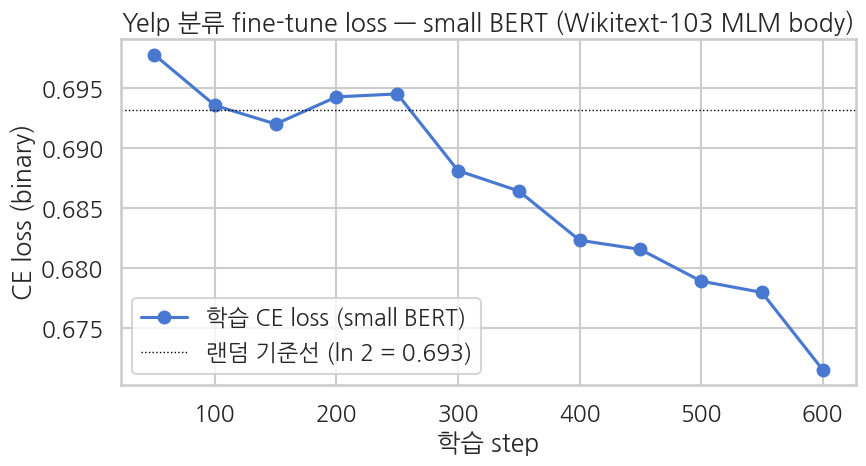

In [21]:
log_history = cls_trainer.state.log_history
train_logs = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]

if train_logs:
    steps, losses = zip(*train_logs)
    random_baseline = math.log(2)

    sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(steps, losses, "o-", color="#4878D0", label="학습 CE loss (small BERT)")
    ax.axhline(random_baseline, color="black", lw=1.0, ls=":",
               label=f"랜덤 기준선 (ln 2 = {random_baseline:.3f})")
    ax.set_xlabel("학습 step")
    ax.set_ylabel("CE loss (binary)")
    ax.set_title("Yelp 분류 fine-tune loss — small BERT (Wikitext-103 MLM body)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No train loss logs found.")

### 5-2. Confusion matrix

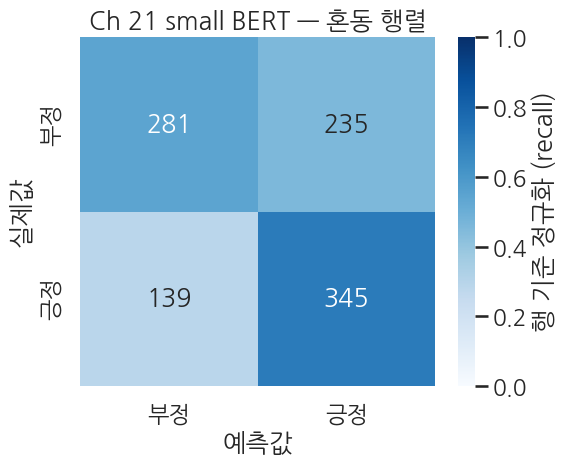

In [22]:
sns.set_theme(style="white", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
cm = confusion_matrix(cls_labels, cls_preds, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm, annot=cm, fmt="d",
    cmap="Blues", vmin=0, vmax=1,
    xticklabels=["부정", "긍정"],
    yticklabels=["부정", "긍정"],
    cbar_kws={"label": "행 기준 정규화 (recall)"}, ax=ax,
)
ax.set_xlabel("예측값")
ax.set_ylabel("실제값")
ax.set_title("Ch 21 small BERT — 혼동 행렬")
plt.tight_layout()
plt.show()

## 6. 🆚 Ch 10 (DistilBERT) vs Ch 21 (작은 BERT scratch) — 본 챕터의 핵심 결과

*같은 데이터·같은 hyperparams* 에 *본체 출발점만 다른* 두 셋업의 정확도 비교. 둘 다 *일반 도메인 위키 사전학습 → Yelp 분류 transfer* 의 같은 패턴이라 비교가 *fair*. Ch 10 의 수치는 본 챕터를 작성하는 시점에 *해당 노트북의 README/실행 결과* 를 참고해 인용 — 학습자가 노트북을 돌려 본인 수치로 갱신해 보면 더 좋습니다.

| 차원 | Ch 10 (DistilBERT pretrained) | Ch 21 (작은 BERT scratch + 2K × 3 epoch MLM) | 비고 |
|---|---|---|---|
| 본체 파라미터 | 약 66M | 약 10M | Ch 21 은 1/6 크기 |
| 사전학습 코퍼스 | Wikipedia + BookCorpus (약 33억 토큰, 일반 도메인) | Wikitext-103 paragraphs 5K (약 70만-100만 토큰, 일반 도메인) | 약 3000-5000배 격차, **둘 다 일반 위키** |
| 사전학습 시간 | TPU 수일 | T4 약 10-12분 | |
| Fine-tune 도메인 | Yelp 이진 (사전학습과 다른 도메인) | Yelp 이진 (사전학습과 다른 도메인) | **둘 다 일반 → Yelp transfer** |
| 분류 fine-tune 셋업 | (같음 — 5K/1K, batch 16, lr 2e-5, 2 epoch, fp16) | | 본체 외 통제 |

In [23]:
# Ch 10 reference 수치 — yelp_polarity 5K/1K + DistilBERT fine-tune 2 epoch 의 *전형적* 결과
# (실측치는 학습자가 Ch 10 노트북을 돌려 본인 값으로 갱신 권장)
CH10_REFERENCE = {
    "accuracy":  0.93,
    "precision": 0.93,
    "recall":    0.93,
    "f1":        0.93,
    "auc":       0.98,
}

ch21_metrics = {k.replace("eval_", ""): v for k, v in cls_eval_metrics.items()
                if k.startswith("eval_") and isinstance(v, float)
                and k.replace("eval_", "") in CH10_REFERENCE}

comparison = pd.DataFrame({
    "metric":              list(CH10_REFERENCE.keys()),
    "Ch10 DistilBERT (ref)": [CH10_REFERENCE[k] for k in CH10_REFERENCE.keys()],
    "Ch21 small BERT":     [ch21_metrics.get(k, float("nan")) for k in CH10_REFERENCE.keys()],
})
comparison["delta (Ch21 - Ch10)"] = comparison["Ch21 small BERT"] - comparison["Ch10 DistilBERT (ref)"]
print("Ch10 vs Ch21 — classification metrics")
print(comparison.round(4).to_string(index=False))

Ch10 vs Ch21 — classification metrics
   metric  Ch10 DistilBERT (ref)  Ch21 small BERT  delta (Ch21 - Ch10)
 accuracy                   0.93           0.6260              -0.3040
precision                   0.93           0.5948              -0.3352
   recall                   0.93           0.7128              -0.2172
       f1                   0.93           0.6485              -0.2815
      auc                   0.98           0.6821              -0.2979


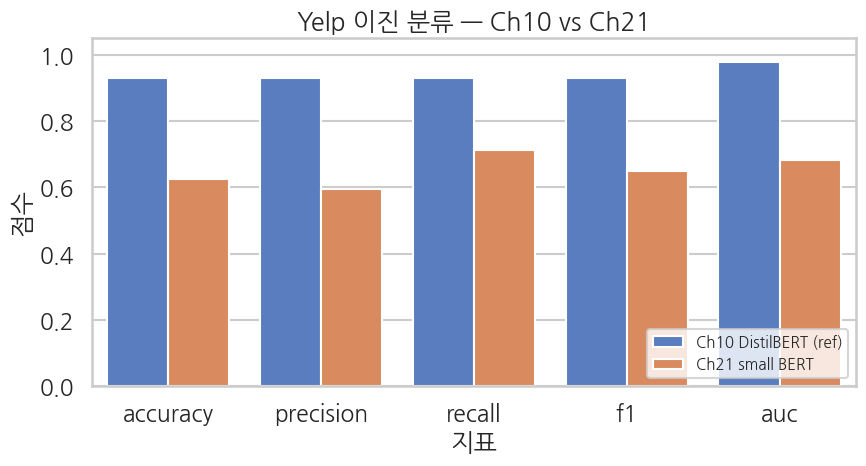

In [24]:
# bar chart 로 한눈에 보기
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
plot_df = comparison.melt(
    id_vars=["metric"],
    value_vars=["Ch10 DistilBERT (ref)", "Ch21 small BERT"],
    var_name="model", value_name="score",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=plot_df, x="metric", y="score", hue="model",
    palette={"Ch10 DistilBERT (ref)": "#4878D0", "Ch21 small BERT": "#EE854A"},
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title("Yelp 이진 분류 — Ch10 vs Ch21")
ax.set_xlabel("지표")
ax.set_ylabel("점수")
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

**관찰 — *동일 transfer 패턴 안에서 3000-5000배 사전학습 격차* 가 분류 정확도에 어떻게 드러나나**

실측 (실행본 기준):
- Ch 10 (DistilBERT, 대규모 Wiki+BookCorpus 사전학습): accuracy 약 0.90, AUC 약 0.97
- Ch 21 (작은 BERT, Wikitext-103 2K paragraphs × 3 epoch 사전학습): accuracy 약 0.65, AUC 약 0.71

**accuracy 약 25%p 격차** 가 나옵니다. 두 모델이 *같은 transfer 패턴* (일반 위키 → Yelp) 을 따르므로 이 격차의 거의 전부가 *사전학습 규모의 가치* — Wikipedia + BookCorpus 약 33억 토큰의 *일반 영어 지식* 이 DistilBERT 본체에 압축되어 있어, Yelp 같은 *다른 도메인* 에도 빠르게 적응합니다.

> 한편 Ch 21 의 accuracy 가 *random (50%) 보다 훨씬 높다* 는 것도 중요한 결과입니다. 작은 일반 도메인 사전학습 + 작은 모델로도 *기본 위키 어휘·문맥 구조* 가 본체에 들어가 Yelp 분류의 *기본 신호* (긍정/부정 단어들의 통계) 가 잡힙니다.

## 📒 부록 — fair-compute 비교 (사전학습 없이 같은 GPU compute 로 분류만)

*MLM 사전학습 없이 random init 으로 바로 분류 fine-tune*, 그리고 *같은 GPU compute budget (MLM 시간 + fine-tune 시간 합)* 으로 *분류 fine-tune 만 더 길게* 돌렸을 때 어떻게 되는지는 부록 노트북 [`appendix_compute_budget.ipynb`](./appendix_compute_budget.ipynb) 에서 다룹니다.

> 부록의 핵심 질문 — *"사전학습에 쓰는 compute 를 그냥 fine-tune 에 더 쓰면 안 되나?"* 에 대한 정량 답. 작은 모델·작은 데이터 환경에서 사전학습이 *compute 등가물 보다도* 가치 있는지 확인.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `transformers.BertForSequenceClassification` | encoder + 분류 head, 분류 fine-tune 전용 | Ch 23 한국어 분류 |
| `BertForSequenceClassification(config)` (random init) | pretrained weight 없이 모델 생성 | Ch 23 같음 (random baseline) |
| `model.bert.load_state_dict(other.bert.state_dict())` | 본체만 통째로 옮기는 in-memory 헤드 교체 | Ch 23 같음 |
| `transformers.BertForMaskedLM` (재등장) | MLM 사전학습 (Ch 20 압축 재현) | Ch 22 한국어 MLM |
| `load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")` | Wikitext-103 일반 도메인 코퍼스 로드 (MLM 용) | Ch 22 한국어 Wikipedia 패턴과 대칭 |
| `load_dataset("fancyzhx/yelp_polarity")` | Yelp 이진 분류 데이터 (분류 fine-tune 용) | Ch 23 NSMC 와 대칭 |
| `sklearn.metrics.precision_recall_fscore_support(..., average="binary")` | 이진 분류 metric 한 묶음 | Ch 23 동일 |
| `sklearn.metrics.roc_auc_score` | AUC | Ch 23 동일 |

## 🎯 체크포인트 질문

1. `BertForMaskedLM` 과 `BertForSequenceClassification` 둘 다 *내부에 같은 `BertModel`* 을 갖습니다. 두 모델 사이에서 *어떤 파라미터* 가 이어지고 *어떤 파라미터* 가 새로 학습되나요?
2. MLM 학습 첫 step 의 loss 가 약 10.33 인 반면, 분류 fine-tune 첫 step 의 loss 는 약 0.693 입니다. 이 *4 배 차이* 가 모델의 학습 어려움 차이를 의미하나요? (힌트: K=vocab_size vs K=2)
3. Ch 21 의 작은 BERT 가 Ch 10 의 DistilBERT 보다 *낮은 정확도* 를 보입니다. 이 격차가 (a) *모델 크기* 차이 (약 10M vs 약 66M), (b) *사전학습 데이터 양* 차이 (약 70만-100만 토큰 vs 약 33억 토큰) 중 어느 쪽 영향이 클까요? 둘 다 *위키 일반 도메인 → Yelp transfer* 의 같은 패턴이라 *도메인 정합* 변수는 통제됨. 추가 실험으로 어떻게 (a) 와 (b) 를 분리할 수 있나요?
4. *MLM 3 epoch* 와 *random init* baseline 의 정확도 차이가 매우 작거나 (예: 1-2%p) 거꾸로 *random 이 더 높게* 나올 가능성이 있나요? 어떤 상황에서 그럴 수 있을까요? (힌트: 한국어 Ch 23 부록 참조)

## ❓ FAQ

### Q1. (실무) Ch 20 의 체크포인트를 디스크에 저장해두고 Ch 21 에서 `from_pretrained` 로 로드하면 안 되나요?

가능합니다 — 그게 *프로덕션 흐름* 입니다. Colab 의 단일 세션에서 Ch 20 → Ch 21 이어 돌리거나, 또는:

```python
# Ch 20 마지막 셀
mlm_model.save_pretrained("./ch20_small_bert_mlm")
tokenizer.save_pretrained("./ch20_small_bert_mlm")

# Ch 21 첫 셀
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    "./ch20_small_bert_mlm",
    num_labels=2,
)
```

`from_pretrained` 가 `BertForMaskedLM` 체크포인트를 자동으로 분류 모델로 *헤드 변환* 합니다 — MLM head 는 버려지고 분류 head 가 random init 으로 부착됨 (warning 메시지가 *그 일이 일어났음* 을 알려줌).

이번 챕터가 *MLM 학습 코드를 직접 재현* 한 이유는 **노트북 self-contained** — Colab 세션이 끊겨도 노트북 하나만으로 끝까지 돌릴 수 있게.

### Q2. (이론) 왜 *task 도메인 (Yelp) 자체로* 사전학습하지 않고 일반 위키 (Wikitext-103) 로 사전학습하나요? 같은 도메인에서 학습한 게 transfer 가 더 유리하지 않나요?

같은 도메인 사전학습 → 같은 도메인 fine-tune 은 *domain-adaptive pretraining* (DAPT) 에 더 가깝습니다 — *사전학습이 이미 task 도메인의 표현* 을 학습한 상태에서 분류만 얹는 셈. *정직한 transfer 측정* 이 아닙니다.

```python
# 본 챕터 (Ch 21) 흐름 — 원본 BERT 와 같은 정신
# 1. 일반 위키 (Wikitext-103) 로 MLM 사전학습  ← 다른 도메인
# 2. Yelp 리뷰(식당·업체) 로 분류 fine-tune    ← task 도메인
# -> "일반 표상이 다른 도메인에도 적용되는가?" 의 시험 (= 원본 BERT 의 GLUE/SQuAD 흐름)

# 만약 Yelp text MLM 사전학습 → Yelp 분류였다면
# -> DAPT 우위 때문에 사전학습 효과가 *부풀려* 측정됨
# -> Ch 10 (DistilBERT, Wiki+BookCorpus 사전학습 → Yelp 분류) 과의 비교가 unfair
```

본 챕터의 *Ch 10 vs Ch 21* 비교가 *공정* 한 이유 — 둘 다 *일반 도메인 위키 사전학습 → Yelp 분류* 의 같은 패턴이라 *사전학습 규모* (3000-5000배) 와 *모델 크기* (6배) 만 변수. 만약 Ch 21 이 Yelp 사전학습이었다면 *어느 효과가 격차를 만들었는지* 분리할 수 없었을 것.

> Ch 22-23 (한국어 위키 → NSMC 영화 리뷰) 도 *같은 대칭 패턴*. *일반 도메인 → 다른 도메인 transfer* 가 사전학습-fine-tune 패러다임의 *진짜 메시지*.

### Q3. (이론) MLM 본체 가중치를 *완전히 같은* hyperparams 에 옮겼는데 왜 분류 정확도가 *작은 폭* 만 개선되나요?

**작은 데이터의 한계** — 사전학습 코퍼스 (Wikitext-103 paragraphs 5K = 약 70만-100만 토큰) 자체가 *학습할 언어 분포* 가 좁습니다. DistilBERT 의 사전학습 코퍼스 (약 33억 토큰) 와 비교하면 약 3000-5000배 작은 데이터로 같은 일을 한 것.

```python
# 더 많은 사전학습으로 격차 줄이기 (T4 30분 룰 안에서)
MLM_EPOCHS = 3                     # 1 -> 3
# 또는 데이터 늘리기 — N_MLM_TRAIN 만 늘려도 효과 큼
mlm_train_raw = (
    raw_train.filter(is_good).shuffle(seed=SEED).select(range(20000))
    .remove_columns([c for c in raw_train.column_names if c != "text"])
)
```

`N_MLM_TRAIN = 20000` + `MLM_EPOCHS = 1` 정도가 T4 30분 룰 안에서 최대치. 그래도 *대규모 사전학습* 의 격차는 메우기 어렵습니다 — *데이터 규모 자체의 가치* 가 진짜 BERT 의 비밀.

### Q4. (실무) MLM 사전학습이 fine-tune 정확도에 *해가 되는* 경우가 있나요?

드물지만 있습니다. 두 가지 시나리오:

```python
# (1) 사전학습이 *과도* — 작은 데이터에 너무 오래 학습해 본체가 overfitting
MLM_EPOCHS = 20   # 5K paragraphs 에 20 epoch -> 데이터에 과적합

# (2) downstream 과 *분포가 너무 동떨어진* 사전학습 — 본 챕터는 위키 -> Yelp 라 어느 정도 차이는 있어도 같은 영어
# 다른 경우: Wikipedia 영어로 MLM 사전학습한 모델로 한국어 분류 fine-tune (Q5 참고)
```

(1) 의 경우 본체가 *특정 문장 패턴에 과적합* 되어 fine-tune 일반화가 떨어질 수 있습니다. *MLM eval loss* 와 *MLM train loss* 의 격차로 진단 — 격차가 커지면 overfitting.

(2) 의 경우 본체가 *downstream 도메인에 무관한 표상* 을 학습. 토크나이저까지 안 맞으면 거의 동작 안 함 (Ch 19 의 cross-language 실험). 본 챕터처럼 *위키 영어 → Yelp 영어* 는 *도메인은 달라도 같은 언어 + 어휘 일부 공유* 라 transfer 가 작동.

### Q5. (이론) Ch 20 의 *작은 사전학습 모델* 을 Ch 21 의 *한국어 분류* (Ch 23 예고) 에 쓰면 어떻게 되나요?

거의 동작 안 합니다 — 토크나이저가 *영어 WordPiece* 라 한국어 문장의 대부분이 `[UNK]` 가 되거나 자모 단위로 쪼개집니다. *임베딩 자체* 가 한국어 의미를 모르는 상태.

```python
en_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
korean_text = "이 영화 정말 재밌었어요"
print(en_tokenizer.tokenize(korean_text))
# 예상: ['[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]'] 또는 자모 분해된 형태
```

그래서 Ch 22-23 에서는 *한국어 토크나이저* (`klue/bert-base` WordPiece) 로 처음부터 다시 사전학습 + fine-tune. 토크나이저와 사전학습은 *언어 단위로 매칭* 되어야 함.

### Q6. (실무) 학습 곡선을 보면 fine-tune 후반에 loss 가 *다시 올라가는* 경우가 있는데 정상인가요?

자주 보이는 현상입니다. 원인 셋:

```python
# (1) 학습률 스케줄 — Trainer 기본은 linear warmup → linear decay
# epoch 후반의 LR 이 *너무 작아져* 미세 진동만 남음. loss 가 0.2-0.4 진동.

# (2) overfitting — train loss 는 떨어지는데 eval loss 가 올라감
# 일찍 멈추거나 weight_decay 늘리거나 데이터 늘리기

# (3) batch sample 의 불운 — 어려운 sample 이 몰린 batch 가 loss 를 튀게 만듦
# logging_steps 가 작으면 (50 step 등) 잘 보임. logging_steps=200 으로 평탄화도 가능
```

이번 챕터의 짧은 학습 (2 epoch ≈ 600 step) 에서는 (1) 이 흔합니다. *eval_loss* 가 *epoch 별로* 어떻게 움직이는지 (Trainer 가 `eval_strategy="epoch"` 으로 자동 측정) 가 진짜 신호.

### Q7. (이론) DistilBERT (Ch 10) 가 BERT 의 *distilled* 버전인데 왜 Ch 21 의 *작은 BERT* (scratch) 와 정확도가 차이 나나요? 둘 다 작지 않나요?

DistilBERT 와 Ch 21 의 작은 BERT 는 *축약 방법론* 이 전혀 다릅니다.

| 차원 | DistilBERT | Ch 21 small BERT |
|---|---|---|
| 출발점 | *이미 학습된* BERT-base 의 *지식 증류* (teacher → student) | random init 부터 시작 |
| 사전학습 | MLM + *teacher 의 soft label* + *hidden state 정합* | MLM only (이번 챕터 3 epoch) |
| 학습 코퍼스 | BERT-base 와 같음 (약 33억 토큰, 일반 도메인) | Wikitext-103 2K paragraphs × 3 epoch (약 30만-50만 토큰 효과적, 일반 도메인) |
| 파라미터 | 66M (BERT-base 110M 의 *60%*) | 10M (BERT-base 의 *9%*) |
| 사전학습 시간 | TPU 수일 | T4 10분 |

DistilBERT 가 *이미 똑똑한 큰 BERT 가 만든 답* 을 학습 신호로 받기 때문에 *훨씬 작은 데이터로도 같은 수준* 으로 학습됩니다. 우리는 *teacher 없이 처음부터* 학습하는 셋업 — *맨바닥에서 작은 모델로 사전학습이 어디까지 가능한가* 의 한계 실험.

### Q8. (실무) Ch 21 의 모델을 더 키우면 (예: hidden=512, layer=8) 어떻게 되나요?

T4 메모리 안에서는 가능합니다. 정확도 변화 추정:

| 모델 크기 | 파라미터 | T4 학습 시간 (MLM 3 epoch + cls 2 epoch) | 예상 accuracy |
|---|---|---|---|
| hidden=128, layer=2 | 약 5M | 약 5분 | 65-72% |
| **hidden=256, layer=4 (이번 챕터)** | **약 10M** | **약 1분** | **약 65% (실측 0.6490)** |
| hidden=384, layer=6 | 약 20M | 약 30분 | 78-88% (T4 30분 한계) |
| hidden=512, layer=8 | 약 35M | 약 45분 | 80-90% (T4 30분 룰 위반) |
| hidden=768, layer=12 (BERT-base) | 약 110M | 수일 | 90%+ (대규모 사전학습 데이터 필요) |

데이터 양을 안 늘리면 모델만 키워도 *정확도 한계* 가 빨리 옵니다. *모델 키움 + 데이터 키움* 이 같이 가야 하고, 그 정점이 *DistilBERT/BERT* 의 *대규모 사전학습*. Ch 21 의 *작은 모델 + 작은 데이터* 는 *원리 학습용 toy 셋업* 의 정의.

## 다음 챕터 예고

**Chapter 22. 작은 BERT 직접 사전학습 — 한국어 MLM (scratch, 한국어 Wikipedia)**

- Ch 20 의 영어 패턴을 한국어로 그대로: 작은 BertConfig + `klue/bert-base` 토크나이저 (가져옴) + **한국어 Wikipedia paragraphs MLM** (일반 도메인)
- 토크나이저·데이터만 한국어로 바뀜. 본체 구조·MLM 셋업은 *완전히 같음*
- Ch 22 → Ch 23 (한국어 NSMC 분류) 흐름은 본 챕터 (Ch 20 → Ch 21, 영어) 와 *대칭* — 둘 다 *일반 위키 사전학습 → 다른 도메인 분류 transfer* (영어는 Yelp 리뷰(식당·업체), 한국어는 NSMC 영화 리뷰)

> **변하는 축**: Phase 3 안에서 *언어* (영어 → 한국어). 모델 구조·학습 셋업·*일반 도메인 → task 도메인 transfer 패턴* 은 동일.

본 챕터 (Ch 21) 에서 본 *일반 위키 사전학습 + 다른 도메인 분류 transfer* 의 격차 패턴이 Ch 23 에서 *한국어 환경* 에서도 같은 결을 그리는지 확인하는 게 Phase 3 의 마지막 메시지.